In [15]:
# NOTEBOOK NAME
# HorzPlotsFeatureDotLines.ipynb
# NOTEBOOK NAME

# # OPENING IMPORTS
import numpy as np
from matplotlib import pyplot as plt
import xarray as xr

from pathlib import Path      # used to play with pathnames to save

from PIL import Image         # used for creating gif loops
import os                     # used for retrieving file names

import matplotlib.dates as mdates # for putting dates on the time axis of plots

# mapping things
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io import shapereader

from matplotlib.collections import LineCollection # plotting many lines at once

# for adding lat/lon gridlines on plots
import matplotlib.ticker as mticker
from cartopy.mpl.gridliner import LATITUDE_FORMATTER, LONGITUDE_FORMATTER

# SPECIAL METHOD TO IMPORT CUSTOM FUNCTIONS AND ELEVATION FROM LOCAL DIRECTORY
import sys
sys.path.append('/home/563/sg3241/Notebooks/CustomFunctions')
sys.path.append('/home/563/sg3241/Notebooks/CustomFeatureTracking')
from CustomFunctions1 import *
# from CustomTracking import *

# # for adding a colourful topo base map to the CAPI plots
from custom_elevation import fetch_srtm, fetch_gebco_local
# from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import ListedColormap, BoundaryNorm, Normalize
import matplotlib.colors as mcolors

# from scipy.stats import gaussian_kde # for plotting kernel density plots

In [38]:
# HORIZONTAL CROSS SECTION PLOTTING (LOADS IN FROM NET CDF FILES STORED IN SCRATCH)
# (LOADS IN FROM NET CDF FILES STORED IN SCRATCH)

# CHOOSE YOUR RADAR

# Radar Number Catalogue:
# Down The Coast YES Dual-Pol: 22 is Mackay,    106 is Townsville, 66 is Mt Staplyton (Brisbane) , 50 is Marburg (near Bris)
# Down The Coast not Dual-Pol: 19 is Cairns,    8 is Gympie
# Down The Coast NO DOPPLER:   24 is Bowen,     23 is Gladstone (SPECIAL ELEVATION ANGLES)
# 0.8, 1.6, 2.4
# 3.6, 5.6
# 8.0, 11.5
# 16.0, 22.0, 32.0
#Inland
# Down inland YES Dual-Pol:    74 is Greenvale, 98 is Taroom,    108 is Towoomba
# Down inland not Dual-Pol:    78 is Weipa,     72 is Emerald
RadarIDno = '22' 

# CHOOSE THE DATE
# the day in consideration (YYYYMMDD) and time (hhmmss)       ALL IN UTC !!!
RadarYear  = 2024
RadarMonth = 3
RadarDay   = 9
# CHOOSE THE MINUTES YOU WANT TO LOOP OVER (5-MIN PERIODS) (INCLUSIVE OF START AND END TIMES)
LoopStartTime = '12:00'
LoopEndTime   = '12:00'
# LoopEndTime   = '23:55'

# CHOOSE YOUR ALTITUDE
Altitude = 2000  # [m] choose a multiple of 500 m to look at a CAPI for

# CHOOSE YOUR VARIABLE
Var = 'Z'
# LIST OF POSSIBLE VARIABLES
# [Z]         'corrected_reflectivity'
# [CC]        'corrected_cross_correlation_ratio'
# [ZDR]       'corrected_differential_reflectivity'
# [KDP]       'corrected_specific_differential_phase'
# [PhiDP]     'corrected_differential_phase'
...
# [V]         'corrected_velocity'

# VARIABLES NOT YET INCLUDED IN THE CODE
# [IntAtt]    'path_integrated_attenuation'
# [DifIntAtt] 'path_integrated_differential_attenuation'
# [EchClas]   'radar_echo_classification'
...
# [AzSh]      'azshear'



# CHOOSE YOUR QUALITY CONTROL SETTINGS
# taken from Aragon et al. 2024
MinValidZDR = -4 # NO VALID DATA TO USE THE OPTION YET
MaxValidZDR =  4 # NO VALID DATA TO USE THE OPTION YET
MinValidRhoHV = 0.85

# radar choice follow-on
if (RadarIDno == '22'):
    RadarSiteName = 'Mackay'
elif (RadarIDno == '106'):
    RadarSiteName = 'Townsville'
elif (RadarIDno == '66'):
    RadarSiteName = 'Mt Staplyton'
elif (RadarIDno == '50'):
    RadarSiteName = 'Marabong'
else:
    RadarSiteName = 'Site ' + RadarIDno


# date choice follow-on
# add leading zeros for strings
YYYY = str(RadarYear).zfill(4)
MM = str(RadarMonth).zfill(2)
DD = str(RadarDay).zfill(2)
# write out the data in one string with and without dashes
RadarFileDate  = YYYY + MM + DD
RadarFileDatePrint = YYYY + '-' + MM + '-' + DD


# variable choice follow-on
if (Var == 'Z'):
    VarName     = 'Reflectivity'
    VarNameLong = 'corrected_reflectivity'
    VarMinVal =  -10 # [dBZ]
    VarMaxVal =   65 # [dBZ]
    VarUnit   = 'dBZ'
    VarColourBar = 'ocean'
    # fix the colour bar to all values no matter which range you choose to view
    VarColourBar_min = -20.0
    VarColourBar_max = 45.0
    VarColourBar_norm = Normalize(vmin=VarColourBar_min, vmax=VarColourBar_max)

elif (Var == 'ZDR'):
    VarName     = 'Differential Reflectivity'
    VarNameLong = 'corrected_differential_reflectivity'
    VarMinVal = -5 # [dB]
    VarMaxVal =  5 # [dB]
    VarUnit   = 'dB'
    VarColourBar = 'RdBu'
elif (Var == 'CC'):
    VarName     = 'Correlation Coefficient'
    VarNameLong = 'corrected_cross_correlation_ratio'
    VarMinVal = 0.8 # [0 to 1]
    VarMaxVal = 1.0 # [0 to 1]
    VarUnit   = '-0 to 1'
    VarColourBar = 'nipy_spectral'
elif (Var == 'KDP'):
    VarName     = 'Specific Differential Phase'
    VarNameLong = 'corrected_specific_differential_phase'
    VarMinVal = 0  # [deg/ km]
    VarMaxVal = 10 # [deg / km]
    VarUnit   = 'deg / km'
    VarColourBar = 'nipy_spectral'
elif (Var == 'PhiDP'):
    VarName     = 'Differential Phase'
    VarNameLong = 'corrected_differential_phase'
    VarMinVal = 0  # [deg]
    VarMaxVal = 30 # [deg]
    VarUnit   = 'deg'
    VarColourBar = 'nipy_spectral'
elif (Var == 'V'):
    VarName     = 'Velocity'
    VarNameLong = 'corrected_velocity'
    VarMinVal = -30 # [m/s]
    VarMaxVal =  30 # [m/s]
    VarUnit   = 'm/s'
    VarColourBar = 'RdBu_r'
else:
    raise ValueError("Input Variable '" + Var + "' not available\n" + "Please choose from the following list:\n" + \
          "[Z] 'corrected_reflectivity', [CC] 'corrected_cross_correlation_ratio', [ZDR] 'corrected_differential_reflectivity'\n" + \
          "[KDP] 'corrected_specific_differential_phase', [PhiDP] 'corrected_differential_phase'")


# FEATURE DATA LOADING
# FEATURE DATA LOADING
# FEATURE DATA LOADING
FeatureStoragePath = f'/scratch/v46/sg3241/tmp/NetCDFs/PyFLEXTRKR/Stats/{RadarIDno}/{RadarFileDate}/{RadarIDno}_{RadarFileDate}FeatureStats.nc'
FeatureXR = xr.open_dataset(FeatureStoragePath)

# Create a new time dimension for time of day, instead of just time in a given feature's life
# Generate 288 x 5-minute timestamps to assign as coordinate along the 'times' dimension
RadarFileDatePD = pd.Timestamp(RadarFileDatePrint).date()
FrameTimes = pd.date_range(start=pd.Timestamp(RadarFileDatePD), periods=288, freq='5min')
FeatureXR = FeatureXR.assign_coords(FrameTimes=xr.DataArray(FrameTimes, dims='FrameTimes'))

# add variables that rearrange times by time of day rather than time in a given feature's life
FeatureXR = AddFrameTimeVars(FeatureXR)

# remember these plots are horizontal cross sections
PlotType = 'Horz'
# LOOP OVER EVERY 5 MIN PERIOD IN THE DAY
# Parse start and end times
StartHour, StartMin = int(LoopStartTime.split(':')[0]), int(LoopStartTime.split(':')[1])
EndHour, EndMin     =   int(LoopEndTime.split(':')[0]),   int(LoopEndTime.split(':')[1])

# Convert to total minutes for easy comparison
StartMinOfDay = StartHour * 60 + StartMin
EndMinOfDay = EndHour * 60 + EndMin

for MinOfDay in range(StartMinOfDay, EndMinOfDay + 1, 5):
    # find the old indicies with which this code was written (0-23 for hours, 0-11 for 5-minute periods within hours)
    houri = MinOfDay // 60
    mini  = MinOfDay % 60
        
    RadarFileTime = str(houri).zfill(2) + str(mini).zfill(2) + '00' # write out the time in 6 digits (like 012040 for 01:20:40 AM)
    # add a string of format hh:mm:ss for printing
    RadarFileTimePrint = str(RadarFileTime)[0:2] + ':' + str(RadarFileTime)[2:4] + ':' + str(RadarFileTime)[4:6] 
    
    print('working on ' + RadarFileTimePrint)
    # xgrid = xr.open_dataset('/scratch/v46/sg3241/tmp/NetCDFs/RadarGrids/' + RadarIDno + '/' + YYYY + '/' + MM + '/' + DD + '/' + \
    #                         RadarIDno + '_' + RadarFileDate + '_' + RadarFileTime + '.nc')

    RadarGridsFolder = 'CompressedRadarGrids'
    NetCDFstoragePath = ('/scratch/v46/sg3241/tmp/NetCDFs/' + RadarGridsFolder + '/' + RadarIDno + '/' + YYYY + '/' + MM + '/' + DD + '/'
                                                             + RadarIDno + '_' + RadarFileDate + '_' + RadarFileTime + '.nc')
    # try to load in the netcdf file and if it doesn't work, just keep going through the loop
    try:
        xgrid = xr.open_dataset(NetCDFstoragePath)
    except FileNotFoundError:
        print(f'File missing for {RadarFileTimePrint}, skipping: {NetCDFstoragePath}')
        continue

    # index in the netcdf altitude variable for the altitude you want
    alti = np.where(xgrid.z == Altitude) # this is a double nested array for some reason
    alti = alti[0][0] # take the index out of the double nested array

    # quit out if the altitude does not correspond to one in the netCDF file
    if ( np.size(alti) != 1): 
        raise ValueError( str(Altitude) + ' m is not a valid altitude in the data')


    # ROUGH QUALITY CONTROL SECTION
    # create a mask only where these quality control condtions are met
    ConditionGridA = xgrid['corrected_differential_reflectivity'] > MinValidZDR   # (y, x) boolean masks
    
    # I WOULD LIKE TO ADD CONDITIONS WITH DIFFERENTIAL REFLECTIVITY, BUT THIS RADAR DOES NOT HAVE VALID DATA YET
    # ConditionGridB = xgrid['corrected_differential_reflectivity'] < MaxValidZDR  
    # ConditionGridC = xgrid['corrected_cross_correlation_ratio'] > MinValidRhoHV
    
    ConditionGrid = ConditionGridA #* ConditionGridB * ConditionGridC   # combined boolean mask



    fig, ax = plt.subplots(figsize=(8, 6), 
                           subplot_kw={'projection': ccrs.PlateCarree()})

    # gebco_path = '/home/563/sg3241/QueenslandElevationGEBCO.nc'
    # EXPERIMENTAL TOPO SHADING SECTION
    # EXPERIMENTAL TOPO SHADING SECTION
    # EXPERIMENTAL TOPO SHADING SECTION
    
    # TERRAIN SHADING USING LOCAL GEBCO DEM
    lon_min, lon_max = float(xgrid.lon.min()), float(xgrid.lon.max())
    lat_min, lat_max = float(xgrid.lat.min()), float(xgrid.lat.max())

    try:
        # Path to your GEBCO NetCDF
        gebco_path = '/home/563/sg3241/QueenslandElevationGEBCO.nc'

        # Use the helper to get a subset over the radar domain
        dem_da = fetch_gebco_local(gebco_path, lon_min, lon_max, lat_min, lat_max)

        if dem_da is not None:
            # dem_da is an xarray.DataArray with coords lon, lat
            dem_lon = dem_da.lon.values
            dem_lat = dem_da.lat.values
            dem_data = dem_da.values

            # Make 2D lon/lat grids if necessary
            if dem_lon.ndim == 1 and dem_lat.ndim == 1:
                dem_lon_2d, dem_lat_2d = np.meshgrid(dem_lon, dem_lat)
            else:
                dem_lon_2d, dem_lat_2d = dem_lon, dem_lat

            # Ensure we have some valid data
            valid = np.isfinite(dem_data)
            if not np.any(valid):
                raise ValueError('DEM has no finite values in this domain')

            colours = [
                '#dde4e8',  # 0: pale blue-grey (ocean, < 0 m)
            
                '#c4dec2',  # 1: 0–200 m, pale green
                '#e4edc9',  # 2: 200–400 m, greenish-yellow
                '#f3f0cf',  # 3: 400–600 m, pale yellow-beige
                '#e9d7bd',  # 4: 600–800 m, light tan
                '#ddc4aa',  # 5: 800–1000 m, tan
                '#cfb194',  # 6: 1000–1200 m, light brown
                '#b58f6e',  # 7: > 1200 m, darker brown
            ]
            
            bounds = [
                -1000.0,  # ocean below 0
                0.0,      # 0–200
                200.0,    # 200–400
                400.0,    # 400–600
                600.0,    # 600–800
                800.0,    # 800–1000
                1000.0,   # 1000–1200
                1200.0,   # > 1200
                5000.0,
            ]
            
            cmap_elev = ListedColormap(colours)
            norm = BoundaryNorm(bounds, len(colours), clip=True)
            
            # Plot as semi‑transparent background
            elev_plot = ax.pcolormesh(
                dem_lon_2d,
                dem_lat_2d,
                dem_data,
                cmap=cmap_elev,
                norm=norm,
                alpha=0.5,
                transform=ccrs.PlateCarree(),
                # zorder=2,
            )

            # Draw 0 m contour as an accurate coastline
            coast_contour = ax.contour(
                dem_lon_2d,
                dem_lat_2d,
                dem_data,
                levels=[0.0],
                colors='black',
                alpha=0.5,
                linewidths=0.5,
                transform=ccrs.PlateCarree(),
                zorder=15,  # above radar and topo
            )

            # Draw 400 m contour
            coast_contour = ax.contour(
                dem_lon_2d,
                dem_lat_2d,
                dem_data,
                levels=[400.0],
                colors='black',
                alpha=0.5,
                linewidths=0.3,
                transform=ccrs.PlateCarree(),
                zorder=15,  # above radar and topo
            )

            print('Terrain shading (GEBCO, discrete bands) + coastline loaded successfully')

        else:
            raise ValueError('GEBCO DEM returned None')

    except Exception as e:
        print(f'Terrain shading failed: {e}')
        print('Falling back to simple land/ocean shading')
        ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.3, zorder=1)
        ax.add_feature(cfeature.LAND, facecolor='#E8E8E8', alpha=0.3, zorder=2)

    ax.add_feature(cfeature.BORDERS, linewidth=0.5, alpha=0.5, zorder=3)


    # EXPERIMENTAL TOPO SHADING SECTION END
    # EXPERIMENTAL TOPO SHADING SECTION END
    # EXPERIMENTAL TOPO SHADING SECTION END

    # apply the condtional mask to the variable array before plotting
    ValidVariableArray = xgrid[VarNameLong].where(ConditionGrid)
    PlottingArray = ValidVariableArray[0,alti,:,:]

    GridViewer = ax.pcolormesh(xgrid.lon, xgrid.lat, PlottingArray, 
                               cmap=VarColourBar , norm=VarColourBar_norm, transform=ccrs.PlateCarree())

    
    # FEATURE DOT PLOTTING
    # FEATURE DOT PLOTTING
    # FEATURE DOT PLOTTING

    # Derive the timestamp and find the matching FrameTimes index
    RadarFileTimeStamp = pd.Timestamp(f'{RadarFileDatePrint}T{RadarFileTimePrint}').floor('5min')
    TimeIndex = pd.DatetimeIndex(FeatureXR['FrameTimes'].values).get_loc(RadarFileTimeStamp)


    # Extract values at this time index
    PlotLons = FeatureXR['meanlon_frametimes'].sel(FrameTimes=FeatureXR['FrameTimes'][TimeIndex]).values
    PlotLats = FeatureXR['meanlat_frametimes'].sel(FrameTimes=FeatureXR['FrameTimes'][TimeIndex]).values
    
    # Mask to only tracks that exist at this time (i.e. not NaN or -9999)
    ValidMask = ~np.isnan(PlotLons) & ~np.isnan(PlotLats)

    # red dots with white in the middle
    ax.scatter(
        PlotLons[ValidMask],
        PlotLats[ValidMask],
        s         = 6,
        color     = [1.0,0,0],
        transform = ccrs.PlateCarree(),
        zorder    = 25,
    )

    ax.scatter(
        PlotLons[ValidMask],
        PlotLats[ValidMask],
        s         = 1,
        color     = [1,1,1],
        transform = ccrs.PlateCarree(),
        zorder    = 26,
    )

    # NOW FOR THE TRAILING LINES
    # --- Separate tracks into categories ---
    # For each track, find the slice of frametimes up to and including TimeIndex
    TrackLons = FeatureXR['cell_meanlon_frametimes'].values  # shape: (tracks, FrameTimes)
    TrackLats = FeatureXR['cell_meanlat_frametimes'].values  # shape: (tracks, FrameTimes)
    
    Lines        = []  # for LineCollection
    SingleDots_x = []  # one-frame dead features
    SingleDots_y = []
    
    for i in range(TrackLons.shape[0]):
        
        # Get this track's data up to and including TimeIndex
        LonSlice = TrackLons[i, :TimeIndex + 1]
        LatSlice = TrackLats[i, :TimeIndex + 1]
    
        # Valid mask — non-NaN points up to present
        ValidMask = ~np.isnan(LonSlice) & ~np.isnan(LatSlice)
    
        # Skip features that do not exist yet
        if ValidMask.sum() == 0:
            continue
    
        ValidLons = LonSlice[ValidMask]
        ValidLats = LatSlice[ValidMask]
    
        if ValidLons.shape[0] == 1:
            # Single point — add to dot list
            SingleDots_x.append(ValidLons[0])
            SingleDots_y.append(ValidLats[0])
        else:
            # Build coordinate pairs for LineCollection
            Points = np.array([ValidLons, ValidLats]).T  # shape: (n, 2)
            Segments = np.stack([Points[:-1], Points[1:]], axis=1)  # shape: (n-1, 2, 2)
            Lines.append(Segments)
    
    # --- Draw lines ---
    if len(Lines) > 0:
        AllSegments = np.concatenate(Lines, axis=0)
        LC = LineCollection(
            AllSegments,
            color     = [0.55,0,0],
            linewidths = 0.3,
            alpha      = 0.5,
            transform  = ccrs.PlateCarree(),
            zorder     = 24,
        )
        ax.add_collection(LC)
    
    # --- Draw single-point black dots ---
    if len(SingleDots_x) > 0:
        ax.scatter(
            SingleDots_x,
            SingleDots_y,
            s         = 1,
            alpha      = 0.5,
            color     = [0.55,0,0],
            transform = ccrs.PlateCarree(),
            zorder    = 24.5,
        )

    # FEATURE DOT PLOTTING END
    # FEATURE DOT PLOTTING
    # FEATURE DOT PLOTTING END


    cbar = plt.colorbar(GridViewer, ax=ax, label=VarName + ' [' + VarUnit + ']')
    cbar.ax.set_ylim(-VarMinVal, VarMaxVal)          # zoom the displayed range on the colorbar
    cbar.set_ticks(np.arange(VarMinVal, VarMaxVal, 10))  # tick every 10 dBZ

    # Add MINOR gridlines (tenth degrees) - thin
    gl_minor = ax.gridlines(draw_labels=False, alpha=0.8, zorder=11, linewidth=0.2)
    gl_minor.xlocator = mticker.MultipleLocator(0.1)  # Every 0.1 degrees
    gl_minor.ylocator = mticker.MultipleLocator(0.1)  # Every 0.1 degrees

    # Add MID LEVEL gridlines (half degrees) - standard width with labels
    gl_mid = ax.gridlines(draw_labels=True, alpha=0.8, zorder=12, linewidth=0.3)
    gl_mid.xlocator = mticker.MultipleLocator(0.5)  # Every 0.5 degrees
    gl_mid.ylocator = mticker.MultipleLocator(0.5)  # Every 0.5 degrees

    # Add MAJOR gridlines (full degrees) - thick with labels
    gl_major = ax.gridlines(draw_labels=True, alpha=0.8, zorder=13, linewidth=0.6)
    gl_major.xlocator = mticker.MultipleLocator(1.0)  # Every 1.0 degrees
    gl_major.ylocator = mticker.MultipleLocator(1.0)  # Every 1.0 degrees
    
    # Format labels
    gl_mid.xformatter = LONGITUDE_FORMATTER
    gl_mid.yformatter = LATITUDE_FORMATTER
    
    gl_major.xformatter = LONGITUDE_FORMATTER
    gl_major.yformatter = LATITUDE_FORMATTER
    
    # Remove labels from top and right
    gl_mid.top_labels = False
    gl_mid.right_labels = False
    gl_mid.bottom_labels = True
    gl_mid.left_labels = True
    
    gl_major.top_labels = False
    gl_major.right_labels = False
    gl_major.bottom_labels = True
    gl_major.left_labels = True

    # # Add coastlines ON TOP of radar data
    # ax.coastlines(resolution='10m', linewidth=0.5, color='black', zorder=13)
    
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

    plt.title(VarName + ' (ρHV > ' + str(MinValidRhoHV) + ') for ' + RadarSiteName + ' Radar\nat ' + str(Altitude) + ' m Altitude\non ' + \
              RadarFileDate[0:4] + '-' + RadarFileDate[4:6] + '-' + RadarFileDate[6:8] + ' at ' + \
              str(RadarFileTime)[0:2] + ':' + str(RadarFileTime)[2:4] + ':' + str(RadarFileTime)[4:6] + ' UTC')

    SaveFolder = '/scratch/v46/sg3241/tmp/pngImages/' + PlotType + '/' + RadarIDno + '/' + RadarFileDate + '/' + \
                                                                                           VarName + '/RhoHVlim' + str(MinValidRhoHV*100)[0:2] + 'FeatureDotLines/'
                                                                                                      # RhoHV 0.85 becomes 85 in file name
    SaveFile   = RadarIDno + '_' + RadarFileDate + '_' + RadarFileTime + '_' + VarNameLong + '_' + \
                 PlotType + str(Altitude) + 'm.png'
    
    SavePath = SaveFolder + SaveFile
    
    if not Path(SaveFolder).exists():
        print('doing')
        Path(SaveFolder).mkdir(parents=True, exist_ok=True)
    
    plt.savefig(SavePath, bbox_inches='tight', facecolor='w', dpi = 300)
    plt.close()

working on 12:00:00
Terrain shading (GEBCO, discrete bands) + coastline loaded successfully


In [64]:
# HORIZONTAL CROSS SECTION PLOTTING (LOADS IN FROM NET CDF FILES STORED IN SCRATCH)
# (LOADS IN FROM NET CDF FILES STORED IN SCRATCH)

# CHOOSE YOUR RADAR

# Radar Number Catalogue:
# Down The Coast YES Dual-Pol: 22 is Mackay,    106 is Townsville, 66 is Mt Staplyton (Brisbane) , 50 is Marburg (near Bris)
# Down The Coast not Dual-Pol: 19 is Cairns,    8 is Gympie
# Down The Coast NO DOPPLER:   24 is Bowen,     23 is Gladstone (SPECIAL ELEVATION ANGLES)
# 0.8, 1.6, 2.4
# 3.6, 5.6
# 8.0, 11.5
# 16.0, 22.0, 32.0
#Inland
# Down inland YES Dual-Pol:    74 is Greenvale, 98 is Taroom,    108 is Towoomba
# Down inland not Dual-Pol:    78 is Weipa,     72 is Emerald
RadarIDno = '22' 

# CHOOSE THE DATE
# the day in consideration (YYYYMMDD) and time (hhmmss)       ALL IN UTC !!!
RadarYear  = 2024
RadarMonth = 3
RadarDay   = 9
# CHOOSE THE MINUTES YOU WANT TO LOOP OVER (5-MIN PERIODS) (INCLUSIVE OF START AND END TIMES)
LoopStartTime = '12:05'
# LoopEndTime   = '12:00'
LoopEndTime   = '23:55'

# CHOOSE YOUR ALTITUDE
Altitude = 2000  # [m] choose a multiple of 500 m to look at a CAPI for

# CHOOSE YOUR VARIABLE
Var = 'Z'
# LIST OF POSSIBLE VARIABLES
# [Z]         'corrected_reflectivity'
# [CC]        'corrected_cross_correlation_ratio'
# [ZDR]       'corrected_differential_reflectivity'
# [KDP]       'corrected_specific_differential_phase'
# [PhiDP]     'corrected_differential_phase'
...
# [V]         'corrected_velocity'

# VARIABLES NOT YET INCLUDED IN THE CODE
# [IntAtt]    'path_integrated_attenuation'
# [DifIntAtt] 'path_integrated_differential_attenuation'
# [EchClas]   'radar_echo_classification'
...
# [AzSh]      'azshear'



# CHOOSE YOUR QUALITY CONTROL SETTINGS
# taken from Aragon et al. 2024
MinValidZDR = -4 # NO VALID DATA TO USE THE OPTION YET
MaxValidZDR =  4 # NO VALID DATA TO USE THE OPTION YET
MinValidRhoHV = 0.00

# radar choice follow-on
if (RadarIDno == '22'):
    RadarSiteName = 'Mackay'
elif (RadarIDno == '106'):
    RadarSiteName = 'Townsville'
elif (RadarIDno == '66'):
    RadarSiteName = 'Mt Staplyton'
elif (RadarIDno == '50'):
    RadarSiteName = 'Marabong'
else:
    RadarSiteName = 'Site ' + RadarIDno


# date choice follow-on
# add leading zeros for strings
YYYY = str(RadarYear).zfill(4)
MM = str(RadarMonth).zfill(2)
DD = str(RadarDay).zfill(2)
# write out the data in one string with and without dashes
RadarFileDate  = YYYY + MM + DD
RadarFileDatePrint = YYYY + '-' + MM + '-' + DD


# variable choice follow-on
if (Var == 'Z'):
    VarName     = 'Reflectivity'
    VarNameLong = 'corrected_reflectivity'
    VarMinVal =    0 # [dBZ]
    VarMaxVal =   45 # [dBZ]
    VarUnit   = 'dBZ'
    VarColourBar = 'hot'
    # fix the colour bar to all values no matter which range you choose to view
    VarColourBar_min =  0.0
    VarColourBar_max = 45.0
    VarColourBar_norm = Normalize(vmin=VarColourBar_min, vmax=VarColourBar_max)

elif (Var == 'ZDR'):
    VarName     = 'Differential Reflectivity'
    VarNameLong = 'corrected_differential_reflectivity'
    VarMinVal = -5 # [dB]
    VarMaxVal =  5 # [dB]
    VarUnit   = 'dB'
    VarColourBar = 'RdBu'
elif (Var == 'CC'):
    VarName     = 'Correlation Coefficient'
    VarNameLong = 'corrected_cross_correlation_ratio'
    VarMinVal = 0.8 # [0 to 1]
    VarMaxVal = 1.0 # [0 to 1]
    VarUnit   = '-0 to 1'
    VarColourBar = 'nipy_spectral'
elif (Var == 'KDP'):
    VarName     = 'Specific Differential Phase'
    VarNameLong = 'corrected_specific_differential_phase'
    VarMinVal = 0  # [deg/ km]
    VarMaxVal = 10 # [deg / km]
    VarUnit   = 'deg / km'
    VarColourBar = 'nipy_spectral'
elif (Var == 'PhiDP'):
    VarName     = 'Differential Phase'
    VarNameLong = 'corrected_differential_phase'
    VarMinVal = 0  # [deg]
    VarMaxVal = 30 # [deg]
    VarUnit   = 'deg'
    VarColourBar = 'nipy_spectral'
elif (Var == 'V'):
    VarName     = 'Velocity'
    VarNameLong = 'corrected_velocity'
    VarMinVal = -30 # [m/s]
    VarMaxVal =  30 # [m/s]
    VarUnit   = 'm/s'
    VarColourBar = 'RdBu_r'
else:
    raise ValueError("Input Variable '" + Var + "' not available\n" + "Please choose from the following list:\n" + \
          "[Z] 'corrected_reflectivity', [CC] 'corrected_cross_correlation_ratio', [ZDR] 'corrected_differential_reflectivity'\n" + \
          "[KDP] 'corrected_specific_differential_phase', [PhiDP] 'corrected_differential_phase'")


# FEATURE DATA LOADING
# FEATURE DATA LOADING
# FEATURE DATA LOADING
FeatureStoragePath = f'/scratch/v46/sg3241/tmp/NetCDFs/PyFLEXTRKR/Stats/{RadarIDno}/{RadarFileDate}/{RadarIDno}_{RadarFileDate}FeatureStats.nc'
FeatureXR = xr.open_dataset(FeatureStoragePath)

# Create a new time dimension for time of day, instead of just time in a given feature's life
# Generate 288 x 5-minute timestamps to assign as coordinate along the 'times' dimension
RadarFileDatePD = pd.Timestamp(RadarFileDatePrint).date()
FrameTimes = pd.date_range(start=pd.Timestamp(RadarFileDatePD), periods=288, freq='5min')
FeatureXR = FeatureXR.assign_coords(FrameTimes=xr.DataArray(FrameTimes, dims='FrameTimes'))

# add variables that rearrange times by time of day rather than time in a given feature's life
FeatureXR = AddFrameTimeVars(FeatureXR)

# remember these plots are horizontal cross sections
PlotType = 'Horz'
# LOOP OVER EVERY 5 MIN PERIOD IN THE DAY
# Parse start and end times
StartHour, StartMin = int(LoopStartTime.split(':')[0]), int(LoopStartTime.split(':')[1])
EndHour, EndMin     =   int(LoopEndTime.split(':')[0]),   int(LoopEndTime.split(':')[1])

# Convert to total minutes for easy comparison
StartMinOfDay = StartHour * 60 + StartMin
EndMinOfDay = EndHour * 60 + EndMin

for MinOfDay in range(StartMinOfDay, EndMinOfDay + 1, 5):
    # find the old indicies with which this code was written (0-23 for hours, 0-11 for 5-minute periods within hours)
    houri = MinOfDay // 60
    mini  = MinOfDay % 60
        
    RadarFileTime = str(houri).zfill(2) + str(mini).zfill(2) + '00' # write out the time in 6 digits (like 012040 for 01:20:40 AM)
    # add a string of format hh:mm:ss for printing
    RadarFileTimePrint = str(RadarFileTime)[0:2] + ':' + str(RadarFileTime)[2:4] + ':' + str(RadarFileTime)[4:6] 
    
    print('working on ' + RadarFileTimePrint)
    # xgrid = xr.open_dataset('/scratch/v46/sg3241/tmp/NetCDFs/RadarGrids/' + RadarIDno + '/' + YYYY + '/' + MM + '/' + DD + '/' + \
    #                         RadarIDno + '_' + RadarFileDate + '_' + RadarFileTime + '.nc')

    RadarGridsFolder = 'CompressedRadarGrids'
    NetCDFstoragePath = ('/scratch/v46/sg3241/tmp/NetCDFs/' + RadarGridsFolder + '/' + RadarIDno + '/' + YYYY + '/' + MM + '/' + DD + '/'
                                                             + RadarIDno + '_' + RadarFileDate + '_' + RadarFileTime + '.nc')
    # try to load in the netcdf file and if it doesn't work, just keep going through the loop
    try:
        xgrid = xr.open_dataset(NetCDFstoragePath)
    except FileNotFoundError:
        print(f'File missing for {RadarFileTimePrint}, skipping: {NetCDFstoragePath}')
        continue

    # index in the netcdf altitude variable for the altitude you want
    alti = np.where(xgrid.z == Altitude) # this is a double nested array for some reason
    alti = alti[0][0] # take the index out of the double nested array

    # quit out if the altitude does not correspond to one in the netCDF file
    if ( np.size(alti) != 1): 
        raise ValueError( str(Altitude) + ' m is not a valid altitude in the data')


    # ROUGH QUALITY CONTROL SECTION
    # create a mask only where these quality control condtions are met
    ConditionGridA = xgrid['corrected_differential_reflectivity'] > MinValidZDR   # (y, x) boolean masks
    
    # I WOULD LIKE TO ADD CONDITIONS WITH DIFFERENTIAL REFLECTIVITY, BUT THIS RADAR DOES NOT HAVE VALID DATA YET
    # ConditionGridB = xgrid['corrected_differential_reflectivity'] < MaxValidZDR  
    # ConditionGridC = xgrid['corrected_cross_correlation_ratio'] > MinValidRhoHV
    
    ConditionGrid = ConditionGridA #* ConditionGridB * ConditionGridC   # combined boolean mask



    fig, ax = plt.subplots(figsize=(8, 6),
                           subplot_kw={'projection': ccrs.PlateCarree()})
    fig.patch.set_facecolor('#0a0a0a')   # <-- add this line immediately after
    ax.set_facecolor('#0a0a0a')          # <-- and this line


    # gebco_path = '/home/563/sg3241/QueenslandElevationGEBCO.nc'
    # EXPERIMENTAL TOPO SHADING SECTION
    # EXPERIMENTAL TOPO SHADING SECTION
    # EXPERIMENTAL TOPO SHADING SECTION
    
    # TERRAIN SHADING USING LOCAL GEBCO DEM
    lon_min, lon_max = float(xgrid.lon.min()), float(xgrid.lon.max())
    lat_min, lat_max = float(xgrid.lat.min()), float(xgrid.lat.max())

    try:
        # Path to your GEBCO NetCDF
        gebco_path = '/home/563/sg3241/QueenslandElevationGEBCO.nc'

        # Use the helper to get a subset over the radar domain
        dem_da = fetch_gebco_local(gebco_path, lon_min, lon_max, lat_min, lat_max)

        if dem_da is not None:
            # dem_da is an xarray.DataArray with coords lon, lat
            dem_lon = dem_da.lon.values
            dem_lat = dem_da.lat.values
            dem_data = dem_da.values

            # Make 2D lon/lat grids if necessary
            if dem_lon.ndim == 1 and dem_lat.ndim == 1:
                dem_lon_2d, dem_lat_2d = np.meshgrid(dem_lon, dem_lat)
            else:
                dem_lon_2d, dem_lat_2d = dem_lon, dem_lat

            # Ensure we have some valid data
            valid = np.isfinite(dem_data)
            if not np.any(valid):
                raise ValueError('DEM has no finite values in this domain')

            colours = [
                '#1a3a5c',  # 0: ocean (< 0 m)     — medium-dark navy blue
                '#1a4a1a',  # 1: 0–200 m           — medium-dark green (coastal lowlands)
                '#2e4a10',  # 2: 200–400 m         — dark olive green
                '#545040',  # 3: 400–600 m         — muted olive
                '#7a5c3a',  # 4: 600–800 m         — muted brown
                '#a07848',  # 5: 800–1000 m        — muted warm brown
                '#bc9858',  # 6: 1000–1200 m       — muted tan
                '#d4b870',  # 7: > 1200 m          — muted golden (peaks)
            ]
            
            bounds = [
                -1000.0,  # ocean below 0
                0.0,      # 0–200
                200.0,    # 200–400
                400.0,    # 400–600
                600.0,    # 600–800
                800.0,    # 800–1000
                1000.0,   # 1000–1200
                1200.0,   # > 1200
                5000.0,
            ]
            
            cmap_elev = ListedColormap(colours)
            norm = BoundaryNorm(bounds, len(colours), clip=True)
            
            # Plot as semi‑transparent background
            elev_plot = ax.pcolormesh(
                dem_lon_2d,
                dem_lat_2d,
                dem_data,
                cmap=cmap_elev,
                norm=norm,
                alpha=0.5,
                transform=ccrs.PlateCarree(),
                # zorder=2,
            )

            # Draw 0 m contour as an accurate coastline
            coast_contour = ax.contour(
                dem_lon_2d,
                dem_lat_2d,
                dem_data,
                levels=[0.0],
                colors='white',
                alpha=0.5,
                linewidths=0.25,
                transform=ccrs.PlateCarree(),
                zorder=15,  # above radar and topo
            )

            # Draw 400 m contour
            coast_contour = ax.contour(
                dem_lon_2d,
                dem_lat_2d,
                dem_data,
                levels=[400.0],
                colors='white',
                alpha=0.2,
                linewidths=0.25,
                transform=ccrs.PlateCarree(),
                zorder=15,  # above radar and topo
            )

            print('Terrain shading (GEBCO, discrete bands) + coastline loaded successfully')

        else:
            raise ValueError('GEBCO DEM returned None')

    except Exception as e:
        print(f'Terrain shading failed: {e}')
        print('Falling back to simple land/ocean shading')
        ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.3, zorder=1)
        ax.add_feature(cfeature.LAND, facecolor='#E8E8E8', alpha=0.3, zorder=2)

    ax.add_feature(cfeature.BORDERS, linewidth=0.5, alpha=0.5, zorder=3)


    # EXPERIMENTAL TOPO SHADING SECTION END
    # EXPERIMENTAL TOPO SHADING SECTION END
    # EXPERIMENTAL TOPO SHADING SECTION END

    # apply the condtional mask to the variable array before plotting
    ValidVariableArray = xgrid[VarNameLong].where(ConditionGrid)
    PlottingArray = ValidVariableArray[0,alti,:,:]

    GridViewer = ax.pcolormesh(xgrid.lon, xgrid.lat, PlottingArray, 
                               cmap=VarColourBar , norm=VarColourBar_norm, transform=ccrs.PlateCarree())

    
    # FEATURE DOT PLOTTING
    # FEATURE DOT PLOTTING
    # FEATURE DOT PLOTTING

    # Derive the timestamp and find the matching FrameTimes index
    RadarFileTimeStamp = pd.Timestamp(f'{RadarFileDatePrint}T{RadarFileTimePrint}').floor('5min')
    TimeIndex = pd.DatetimeIndex(FeatureXR['FrameTimes'].values).get_loc(RadarFileTimeStamp)


    # Extract values at this time index
    PlotLons = FeatureXR['meanlon_frametimes'].sel(FrameTimes=FeatureXR['FrameTimes'][TimeIndex]).values
    PlotLats = FeatureXR['meanlat_frametimes'].sel(FrameTimes=FeatureXR['FrameTimes'][TimeIndex]).values
    
    # Mask to only tracks that exist at this time (i.e. not NaN or -9999)
    ValidMask = ~np.isnan(PlotLons) & ~np.isnan(PlotLats)

    # cyan dots with white in the middle
    ax.scatter(
        PlotLons[ValidMask],
        PlotLats[ValidMask],
        s         = 6,
        color=[0.0, 0.5, 0.8],
        transform = ccrs.PlateCarree(),
        zorder    = 25,
    )

    ax.scatter(
        PlotLons[ValidMask],
        PlotLats[ValidMask],
        s         = 1,
        color     = [1,1,1],
        transform = ccrs.PlateCarree(),
        zorder    = 26,
    )

    # NOW FOR THE TRAILING LINES
    # --- Separate tracks into categories ---
    # For each track, find the slice of frametimes up to and including TimeIndex
    TrackLons = FeatureXR['cell_meanlon_frametimes'].values  # shape: (tracks, FrameTimes)
    TrackLats = FeatureXR['cell_meanlat_frametimes'].values  # shape: (tracks, FrameTimes)
    
    Lines        = []  # for LineCollection
    SingleDots_x = []  # one-frame dead features
    SingleDots_y = []
    
    for i in range(TrackLons.shape[0]):
        
        # Get this track's data up to and including TimeIndex
        LonSlice = TrackLons[i, :TimeIndex + 1]
        LatSlice = TrackLats[i, :TimeIndex + 1]
    
        # Valid mask — non-NaN points up to present
        ValidMask = ~np.isnan(LonSlice) & ~np.isnan(LatSlice)
    
        # Skip features that do not exist yet
        if ValidMask.sum() == 0:
            continue
    
        ValidLons = LonSlice[ValidMask]
        ValidLats = LatSlice[ValidMask]
    
        if ValidLons.shape[0] == 1:
            # Single point — add to dot list
            SingleDots_x.append(ValidLons[0])
            SingleDots_y.append(ValidLats[0])
        else:
            # Build coordinate pairs for LineCollection
            Points = np.array([ValidLons, ValidLats]).T  # shape: (n, 2)
            Segments = np.stack([Points[:-1], Points[1:]], axis=1)  # shape: (n-1, 2, 2)
            Lines.append(Segments)
    
    # --- Draw lines ---
    if len(Lines) > 0:
        AllSegments = np.concatenate(Lines, axis=0)
        LC = LineCollection(
            AllSegments,
            color      = [0.0, 0.7, 0.9],
            linewidths = 0.3,
            alpha      = 0.3,
            transform  = ccrs.PlateCarree(),
            zorder     = 24,
        )
        ax.add_collection(LC)
    
    # --- Draw single-point black dots ---
    if len(SingleDots_x) > 0:
        ax.scatter(
            SingleDots_x,
            SingleDots_y,
            s         = 1,
            alpha      = 0.3,
            color     = [0.0, 0.7, 0.9],
            transform = ccrs.PlateCarree(),
            zorder    = 24.5,
        )

    # FEATURE DOT PLOTTING END
    # FEATURE DOT PLOTTING
    # FEATURE DOT PLOTTING END


    cbar = plt.colorbar(GridViewer, ax=ax, label=VarName + ' [' + VarUnit + ']')
    cbar.set_label(VarName + ' [' + VarUnit + ']', color='white')
    cbar.ax.yaxis.set_tick_params(color='white')
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

    cbar.ax.set_ylim(-VarMinVal, VarMaxVal)          # zoom the displayed range on the colorbar
    cbar.set_ticks(np.arange(VarMinVal, VarMaxVal, 10))  # tick every 10 dBZ

    # Add MINOR gridlines (tenth degrees) - thin
    gl_minor = ax.gridlines(draw_labels=False, alpha=0.5, zorder=11, linewidth=0.1)
    gl_minor.xlocator = mticker.MultipleLocator(0.1)  # Every 0.1 degrees
    gl_minor.ylocator = mticker.MultipleLocator(0.1)  # Every 0.1 degrees

    # Add MID LEVEL gridlines (half degrees) - standard width, NO LABELS
    gl_mid = ax.gridlines(draw_labels=False, alpha=0.5, zorder=12, linewidth=0.15)
    gl_mid.xlocator = mticker.MultipleLocator(0.5)
    gl_mid.ylocator = mticker.MultipleLocator(0.5)

    # Add MAJOR gridlines (full degrees) - thick with labels
    gl_major = ax.gridlines(draw_labels=True, alpha=0.5, zorder=13, linewidth=0.3)
    gl_major.xlocator = mticker.MultipleLocator(1.0)
    gl_major.ylocator = mticker.MultipleLocator(1.0)
    
    gl_major.xformatter = LONGITUDE_FORMATTER
    gl_major.yformatter = LONGITUDE_FORMATTER
    gl_major.xlabel_style = {'color': 'white', 'fontsize': 9}
    gl_major.ylabel_style = {'color': 'white', 'fontsize': 9}
    
    gl_major.top_labels    = False
    gl_major.right_labels  = False
    gl_major.bottom_labels = True
    gl_major.left_labels   = True
    
    # Remove labels from top and right
    gl_mid.top_labels = False
    gl_mid.right_labels = False
    gl_mid.bottom_labels = True
    gl_mid.left_labels = True
    
    gl_major.top_labels = False
    gl_major.right_labels = False
    gl_major.bottom_labels = True
    gl_major.left_labels = True

    # # Add coastlines ON TOP of radar data
    # ax.coastlines(resolution='10m', linewidth=0.5, color='black', zorder=13)
    
    ax.set_xlabel('Longitude', color='white')
    ax.set_ylabel('Latitude', color='white')
    # ax.tick_params(colors='white')

    plt.title(VarName + ' (ρHV > ' + str(MinValidRhoHV) + ') for ' + RadarSiteName + ' Radar\nat ' + str(Altitude) + ' m Altitude\non ' + \
          RadarFileDate[0:4] + '-' + RadarFileDate[4:6] + '-' + RadarFileDate[6:8] + ' at ' + \
          str(RadarFileTime)[0:2] + ':' + str(RadarFileTime)[2:4] + ':' + str(RadarFileTime)[4:6] + ' UTC',
          color='white')

    SaveFolder = '/scratch/v46/sg3241/tmp/pngImages/' + PlotType + '/' + RadarIDno + '/' + RadarFileDate + '/' + \
                                                                                           VarName + '/RhoHVlim' +  str(int(MinValidRhoHV*100)) + 'FeatureDotLines/'
                                                                                                      # RhoHV 0.85 becomes 85 in file name
    SaveFile   = RadarIDno + '_' + RadarFileDate + '_' + RadarFileTime + '_' + VarNameLong + '_' + \
                 PlotType + str(Altitude) + 'm.png'
    
    SavePath = SaveFolder + SaveFile
    
    if not Path(SaveFolder).exists():
        print('doing')
        Path(SaveFolder).mkdir(parents=True, exist_ok=True)
    
    plt.savefig(SavePath, bbox_inches='tight', facecolor='#0a0a0a', dpi=300)
    plt.close()

working on 12:05:00
Terrain shading (GEBCO, discrete bands) + coastline loaded successfully
working on 12:10:00
Terrain shading (GEBCO, discrete bands) + coastline loaded successfully
working on 12:15:00
Terrain shading (GEBCO, discrete bands) + coastline loaded successfully
working on 12:20:00
Terrain shading (GEBCO, discrete bands) + coastline loaded successfully
working on 12:25:00
Terrain shading (GEBCO, discrete bands) + coastline loaded successfully
working on 12:30:00
Terrain shading (GEBCO, discrete bands) + coastline loaded successfully
working on 12:35:00
Terrain shading (GEBCO, discrete bands) + coastline loaded successfully
working on 12:40:00
Terrain shading (GEBCO, discrete bands) + coastline loaded successfully
working on 12:45:00
Terrain shading (GEBCO, discrete bands) + coastline loaded successfully
working on 12:50:00
Terrain shading (GEBCO, discrete bands) + coastline loaded successfully
working on 12:55:00
Terrain shading (GEBCO, discrete bands) + coastline loaded s

In [4]:
FeatureStoragePath = f'/scratch/v46/sg3241/tmp/NetCDFs/PyFLEXTRKR/Stats/{RadarIDno}/{RadarFileDate}/{RadarIDno}_{RadarFileDate}FeatureStats.nc'
# try to load in the netcdf file and if it doesn't work, just keep going through the loop
try:
    FeatureXR = xr.open_dataset(FeatureStoragePath)
except FileNotFoundError:
    print(f'File missing for {RadarFileTimePrint}, skipping: {FeatureStoragePath}')
    # continue

In [5]:
# Create a new time dimension for time of day, instead of just time in a given feature's life

# Generate 288 x 5-minute timestamps to assign as coordinate along the 'times' dimension
RadarFileDatePD = pd.Timestamp(RadarFileDatePrint).date()
FrameTimes = pd.date_range(start=pd.Timestamp(RadarFileDatePD), periods=288, freq='5min')
FeatureXR = FeatureXR.assign_coords(FrameTimes=xr.DataArray(FrameTimes, dims='FrameTimes'))

In [6]:
# THIS FUNCTION add variables to the xarray data frame
# that rearrange time-based variables to correspond to time of day, not time in feature's life
def AddFrameTimeVars(FeatureXR):
    
    # Derive date from dataset attributes
    RadarFileDatePD = pd.Timestamp(str(FeatureXR.attrs['startdate'])[:8]).date()
    FrameTimes = pd.date_range(start=pd.Timestamp(RadarFileDatePD), periods=288, freq='5min')
    FrameTimesIndices = pd.DatetimeIndex(FrameTimes)
    StartTimeFloors = pd.DatetimeIndex(FeatureXR['start_basetime'].values).floor('5min')

    # Map each track's floored start time to its FrameTimes index
    StartFrameIndices = np.array([FrameTimesIndices.get_loc(t) for t in StartTimeFloors])
    
    # Collect all variables that have 'times' as a dimension
    VarsWithTime= [var for var in FeatureXR.data_vars if 'times' in FeatureXR[var].dims]
    
    NumFrames = len(FrameTimes)  # 288
    NewVars = {}
    
    for var in VarsWithTime:
        OldVar = FeatureXR[var]
        OldValues =  OldVar.values
        OldDims = list(OldVar.dims)
    
        # Determine fill value based on dtype
        if np.issubdtype(OldValues.dtype, np.floating):
            FillValue = np.nan
        else:
            FillValue = -9999
    
        # Replace 'times' with 'FrameTimes' in the dimension list
        NewDims = [d if d != 'times' else 'FrameTimes' for d in OldDims]
    
        # Build the shape of the new array, replacing times axis size with n_frames
        TimeAxis = OldDims.index('times')
        NewShape = list(OldValues.shape)
        NewShape[TimeAxis] = NumFrames
    
        # Initialise new array with fill value
        NewValues = np.full(NewShape, FillValue, dtype=OldValues.dtype)
    
        # --- Fill in data track by track ---
        # Get the index of 'times' axis; handle both (times,) and (tracks, times)
        if 'tracks' in OldDims:
            NumTracks = OldValues.shape[OldDims.index('tracks')]
            for i in range(NumTracks):
                StartIndex = StartFrameIndices[i]
    
                # Slice along tracks axis
                TrackData = np.take(OldValues, i, axis=OldDims.index('tracks'))
    
                # Find valid (non-fill) entries
                if np.issubdtype(OldValues.dtype, np.floating):
                    ValidMask = ~np.isnan(TrackData)
                else:
                    ValidMask = TrackData != -9999
    
                ValidData = TrackData[ValidMask]
                NumValidFrames = len(ValidData)
    
                # How many fit from start_idx to end of day
                EndIndex = min(StartIndex + NumValidFrames, NumFrames)
                TrackFrameLength  = EndIndex - StartIndex
    
                # Place into new array along tracks axis
                if OldDims.index('tracks') == 0:
                    NewValues[i, StartIndex:EndIndex] = ValidData[:TrackFrameLength]
                else:
                    NewValues[StartIndex:EndIndex, i] = ValidData[:TrackFrameLength]
        else:
            # Variable has only (times,) dimension — no track offset to apply
            # Just copy directly; no per-track start index available
            NewValues[:] = OldValues
    
        NewVars[f'{var}_frametimes'] = xr.Variable(
            dims=NewDims,
            data=NewValues,
            attrs=OldVar.attrs
        )
    
    # --- Assign all new variables ---
    FeatureXR = FeatureXR.assign(NewVars)

    return FeatureXR

In [7]:
FeatureXR = AddFrameTimeVars(FeatureXR)

In [10]:
FeatureXR

<xarray.Dataset> Size: 325MB
Dimensions:                         (tracks: 4408, times: 288, FrameTimes: 288)
Coordinates:
  * tracks                          (tracks) int64 35kB 0 1 2 ... 4405 4406 4407
  * times                           (times) int64 2kB 0 1 2 3 ... 285 286 287
  * FrameTimes                      (FrameTimes) datetime64[ns] 2kB 2024-03-0...
Data variables: (12/63)
    track_duration                  (tracks) int32 18kB ...
    base_time                       (tracks, times) datetime64[ns] 10MB 2024-...
    meanlat                         (tracks, times) float32 5MB -21.37 ... nan
    meanlon                         (tracks, times) float32 5MB 149.6 ... nan
    area                            (tracks, times) float32 5MB 1.413e+03 ......
    cloudnumber                     (tracks, times) float64 10MB 1.0 1.0 ... nan
    ...                              ...
    maxETH_10dbz_frametimes         (tracks, FrameTimes) float32 5MB 5.0 ... 1.5
    maxETH_20dbz_frametimes         (tracks, FrameTimes) float32 5MB 4.0 ... nan
    maxETH_30dbz_frametimes         (tracks, FrameTimes) float32 5MB 3.5 ... nan
    maxETH_40dbz_frametimes         (tracks, FrameTimes) float32 5MB 2.5 ... nan
    maxETH_50dbz_frametimes         (tracks, FrameTimes) float32 5MB 1.0 ... nan
    maxrange_flag_frametimes        (tracks, FrameTimes) float32 5MB nan ... nan
Attributes:
    Title:                              Statistics of each track
    Institution:                        Pacific Northwest National Laboratory
    Contact:                            Zhe Feng, zhe.feng@pnnl.gov
    Created_on:                         Thu Jul 30 14:38:43 2026
    startdate:                          20240309.000000
    enddate:                            20240309.235500
    timegap_hour:                       0.25
    time_resolution_hour:               0.08333333333333333
    pixel_radius_km:                    1.0
    pixel_length_km_stats:              [1. 1. 1. 1.]
    pixel_length_km_stats_description:  Pixel length [mean, median, min, max]...

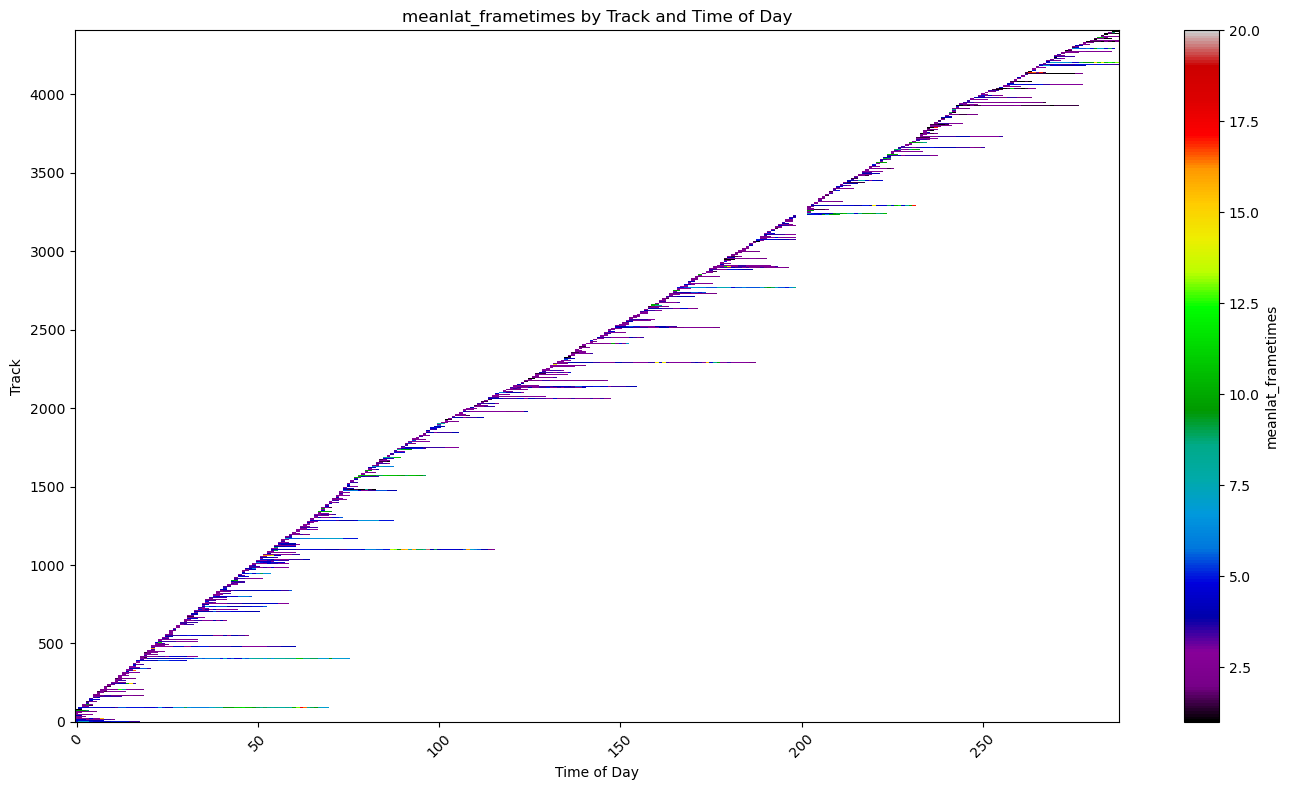

In [11]:
fig, ax = plt.subplots(figsize=(14, 8))

Data   = FeatureXR['maxETH_10dbz_frametimes'].values
FTimes = FeatureXR['times'].values
Tracks = FeatureXR['tracks'].values

mesh = ax.pcolormesh(FTimes, Tracks, Data, cmap='nipy_spectral', shading='auto')
cbar = fig.colorbar(mesh, ax=ax)
cbar.set_label('meanlat_frametimes')

# ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
# ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
plt.xticks(rotation=45)
ax.set_xlabel('Time of Day')
ax.set_ylabel('Track')
ax.set_title('meanlat_frametimes by Track and Time of Day')

plt.tight_layout()
plt.show()


In [30]:
# Parse window start and end
TimeWindowStart = pd.Timestamp(f"{RadarFileDatePrint}T{RadarFileTimePrint}")
TimeWindowEnd = TimeWindowStart + pd.Timedelta(minutes=5)

FeatureStartTimes = np.array(FeatureXR['start_basetime'])

# Find all tracks whose start_basetime falls in [window_start, window_end)
WindowMask = (FeatureStartTimes >= TimeWindowStart) & (FeatureStartTimes < TimeWindowEnd)
MatchingTimeIDs = np.where(WindowMask)[0]

if len(MatchingTimeIDs) == 0:
    print(f"No tracks found starting between {TimeWindowStart} and {TimeWindowEnd}")

LastMatchingTimeID = MatchingTimeIDs[-1]

In [32]:
MatchingTimeIDs

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80])

In [ ]:
# Parse window start and end
window_start = pd.Timestamp(f"{RadarFileDatePrint}{RadarFileTimePrint}")
window_end = window_start + pd.Timedelta(minutes=5)

# Get start_basetime as pandas DatetimeIndex
start_basetimes = pd.DatetimeIndex(ds_trackstats['start_basetime'].values)

# Find all tracks whose start_basetime falls in [window_start, window_end)
mask = (start_basetimes >= window_start) & (start_basetimes < window_end)
matching_idx = np.where(mask)[0]

if len(matching_idx) == 0:
    print(f"No tracks found starting between {window_start} and {window_end}")
    return None, matching_idx

In [5]:
# home/tmp/NetCDFs/PyFLEXTRKR/Stats/22/20240309/trackstats_20240309.000000_20240309.235500.nc

cellid_path   = f'/scratch/v46/sg3241/tmp/NetCDFs/PyFLEXTRKR/Stats/{RadarIDno}/{RadarFileDate}/{RadarIDno}_{RadarFileDate}FeatureStats.nc'

In [8]:
FeatureStoragePath = f'/scratch/v46/sg3241/tmp/NetCDFs/PyFLEXTRKR/Stats/{RadarIDno}/{RadarFileDate}/{RadarIDno}_{RadarFileDate}FeatureStats.nc'
# try to load in the netcdf file and if it doesn't work, just keep going through the loop
try:
    FeatureXR = xr.open_dataset(FeatureStoragePath)
except FileNotFoundError:
    print(f'File missing for {RadarFileTimePrint}, skipping: {FeatureStoragePath}')
    # continue


In [25]:
FeatureStartTimes = np.array(FeatureXR['start_basetime'])

In [26]:
FeatureStartTimes

array(['2024-03-09T00:04:29.000000000', '2024-03-09T00:04:29.000000000',
       '2024-03-09T00:04:29.000000000', ...,
       '2024-03-09T23:59:30.000000000', '2024-03-09T23:59:30.000000000',
       '2024-03-09T23:59:30.000000000'], dtype='datetime64[ns]')

In [10]:
FeatureXR['cell_meanlat']

<xarray.DataArray 'cell_meanlat' (tracks: 4408, times: 288)> Size: 5MB
[1269504 values with dtype=float32]
Coordinates:
  * tracks   (tracks) int64 35kB 0 1 2 3 4 5 6 ... 4402 4403 4404 4405 4406 4407
  * times    (times) int64 2kB 0 1 2 3 4 5 6 7 ... 281 282 283 284 285 286 287
Attributes:
    long_name:  Mean latitude of a convective cell
    units:      degrees_north

In [15]:
FeatureXR['start_basetime'].values

array(['2024-03-09T00:04:29.000000000', '2024-03-09T00:04:29.000000000',
       '2024-03-09T00:04:29.000000000', ...,
       '2024-03-09T23:59:30.000000000', '2024-03-09T23:59:30.000000000',
       '2024-03-09T23:59:30.000000000'], dtype='datetime64[ns]')

In [75]:
# GIF MAKER
# FOR Horizontal Cross Sections

SavedFolder = '/scratch/v46/sg3241/tmp/pngImages/' + PlotType + '/' + RadarIDno + '/' + RadarFileDate + '/' + \
                                                                                       VarName + '/RhoHVlim' +  str(int(MinValidRhoHV*100)) + 'FeatureDotLines/'
                                                                                                  # RhoHV 0.85 becomes 85 in file name         
# LOADING IMAGES
files = sorted(os.listdir(SavedFolder)) # takes all of the files in the folder in the order they are named

images = [Image.open(os.path.join(SavedFolder, f))
    for f in files
    if f.endswith(PlotType + str(Altitude) + 'm.png')]

# DOWNSCALE IMAGES BEFORE MAKING GIF
InverseScaleFactor = 3
ScaleFactor = 1 / InverseScaleFactor
# 0.5 = half resolution, 0.25 = quarter resolution etc.

ResizedImages = []
for img in images:
    NewWidth  = int(img.width  * ScaleFactor)
    NewHeight = int(img.height * ScaleFactor)
    ResizedImages.append(img.resize((NewWidth, NewHeight), Image.LANCZOS))

GIFsaveFolder = '/scratch/v46/sg3241/tmp/gifImages/Horz/' + RadarIDno + '/' + RadarFileDate + '/'
GIFsaveFile   = RadarIDno + '_' + RadarFileDate + '_' + VarName + '_RhoHVlim' +  str(int(MinValidRhoHV*100)) + '_' + str(Altitude) + 'mFeatureDotLines' + str(int(InverseScaleFactor)) + '.gif'

GIFsavePath = GIFsaveFolder + GIFsaveFile

# make a folder to store the new GIF in if one does not exist already
if not Path(GIFsaveFolder).exists():
    Path(GIFsaveFolder).mkdir(parents=True, exist_ok=True)

# Save as looping GIF
ResizedImages[0].save(GIFsavePath, save_all=True, append_images=ResizedImages[1:], duration=200, loop=0)          
                                                                   # ms per frame       0 = loop forever
print('Saved GIF for ' + RadarFileDate)

Saved GIF for 20240309
